In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

Load the Dataset

In [2]:
df = pd.read_csv("Advertising.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.shape

(200, 5)

In [4]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [5]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.drop(columns=['Unnamed: 0'])

Exploratory Data Analysis (EDA)

Correlation Heatmap

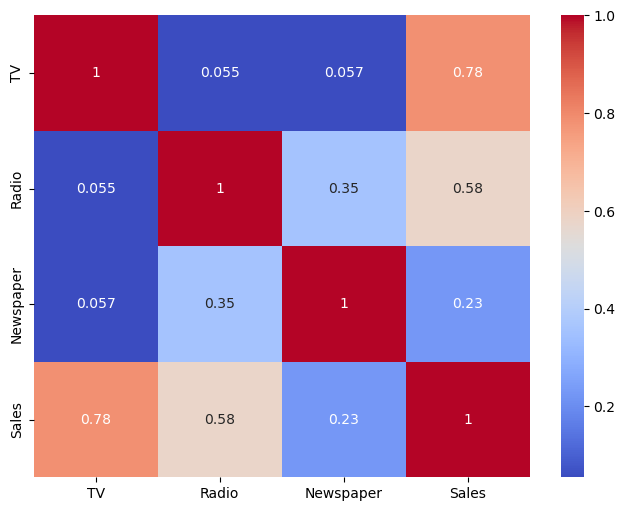

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

Insights: TV has strong positive relation with Sales , 
Radio has moderate relation ,
Newspaper has weak relation .

Pair Plot

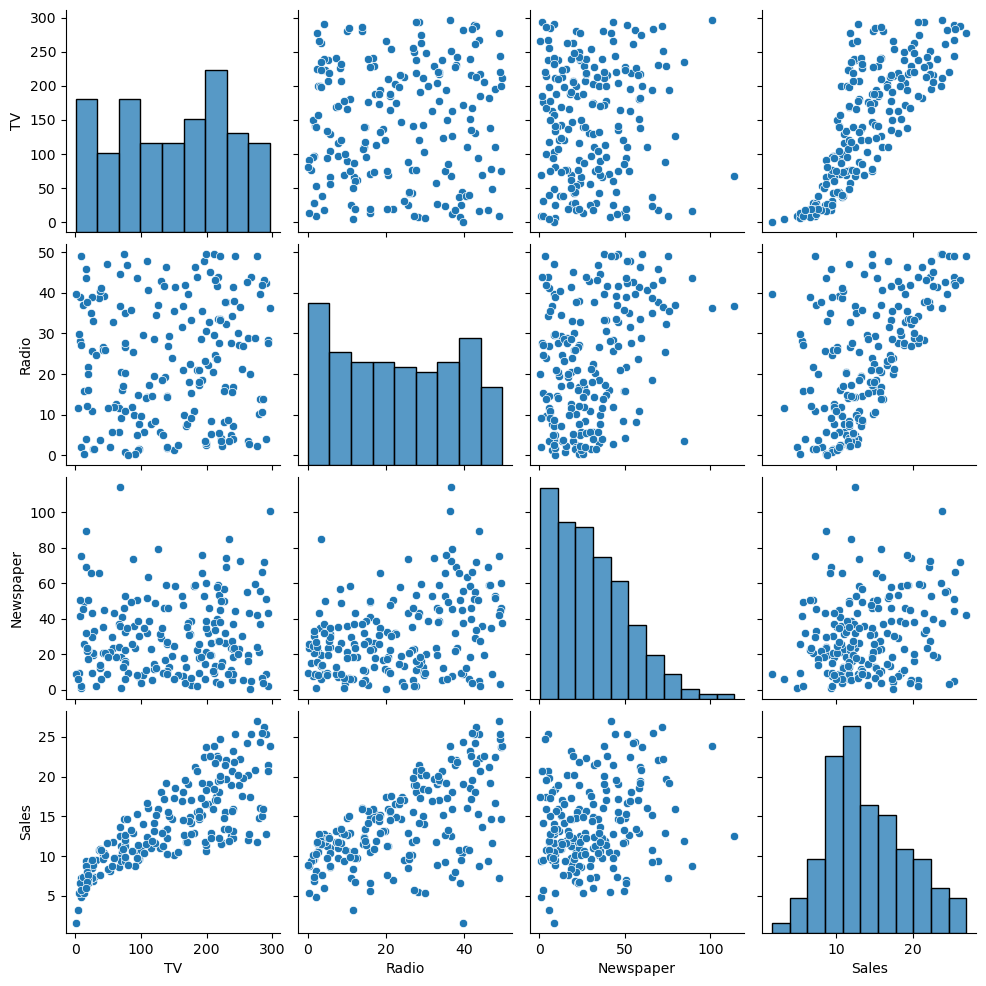

In [32]:
sns.pairplot(df)
plt.savefig("pair_plot.png", bbox_inches="tight")
plt.show()

Scatter Plot

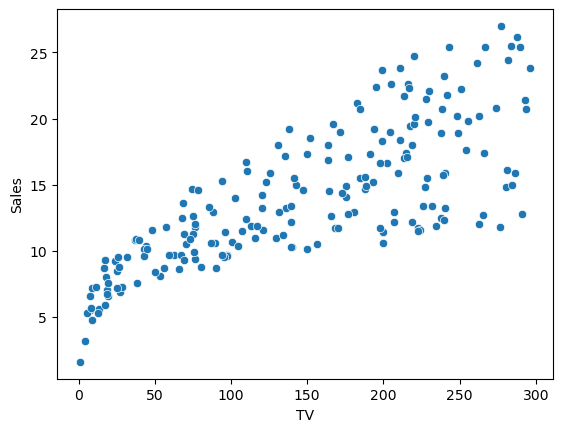

In [33]:
# TV vs Sales
sns.scatterplot(x='TV', y='Sales', data=df)
plt.savefig("TV vs Sales.png", bbox_inches="tight")
plt.show()

Insight: It shows strong upward trend. Increasing TV advertising expenditure is likely to result in higher sales.

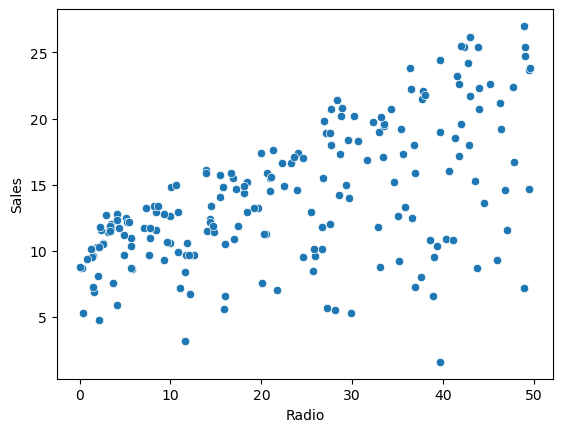

In [11]:
#Radio vs Sales
sns.scatterplot(x='Radio', y='Sales', data=df)
plt.show()

Insight: It shows positive but weaker upward trend. It doesn't guarantee consistent growth.

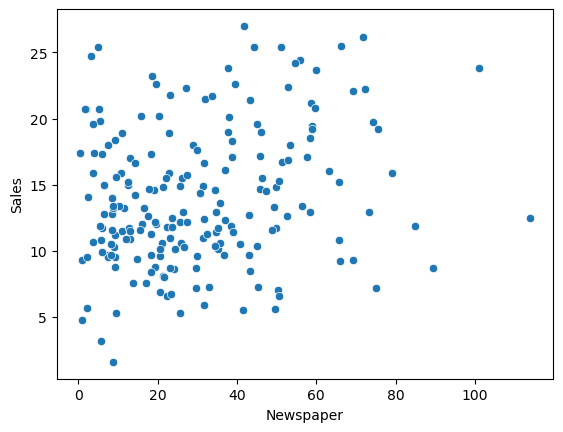

In [12]:
#Newspaper vs Sales
sns.scatterplot(x='Newspaper', y='Sales', data=df)
plt.show()

Insight: Data points are scattered randomly.
No strong upward or downward pattern is visible.

Train/Test Split

In [13]:
from sklearn.model_selection import train_test_split

X = df[['TV','Radio','Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

Model training

Linear Regression 

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = lr.predict(X_test)

In [17]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(results.head())

     Actual  Predicted
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373


Model evaluation

In [18]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 1.4607567168117606


In [19]:
# MSE 
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 3.1740973539761055


In [20]:
# RMSE
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 1.7815996615334506


In [21]:
# R^2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.899438024100912


The model explains 90% of the variation in sales data.

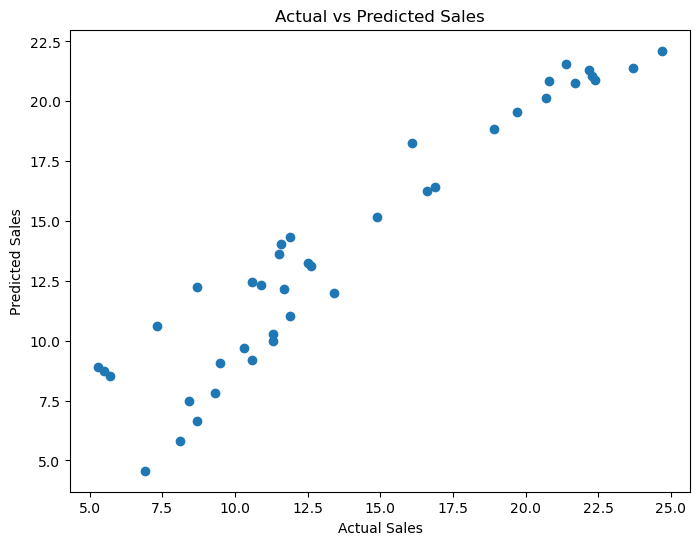

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Insights: The points show a upward trend i.e As Actual Sales increase, Predicted Sales also increase. Most points are clustered close to an imaginary ideal line. 

Random Forest

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
r2 = r2_score(y_test, rf_pred)
print("R2 Score:", r2)

R2 Score: 0.9812843792541843


The model explains 98% of the variation in sales data.

Model Comparison

In [24]:
models = {
    "Linear Regression": lr,
    "Random Forest": rf
}

In [25]:
results = {}

for name, model in models.items():       
    pred = model.predict(X_test)            

    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results[name] = {
        "R2"  : r2,
        "MAE" : mae,
        "RMSE": rmse
    }

    print(f"\n{name}")
    print("R2 Score:", r2)
    print("MAE     :", mae)
    print("RMSE    :", rmse)

best_model = max(results, key=lambda x: results[x]["R2"])
print("\nBest Model:", best_model)


Linear Regression
R2 Score: 0.899438024100912
MAE     : 1.4607567168117606
RMSE    : 1.7815996615334506

Random Forest
R2 Score: 0.9812843792541843
MAE     : 0.6200999999999988
RMSE    : 0.7685910811348248

Best Model: Random Forest


Prediction on New Values

In [34]:
new_data = pd.DataFrame({
    "TV": [100],
    "Radio": [20],
    "Newspaper": [10]
})
prediction = model.predict(new_data)
print("Predicted Sales:", prediction[0])

Predicted Sales: 11.772000000000002


Feature Importance 

In [27]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

     Feature  Importance
0         TV    0.624810
1      Radio    0.362201
2  Newspaper    0.012989


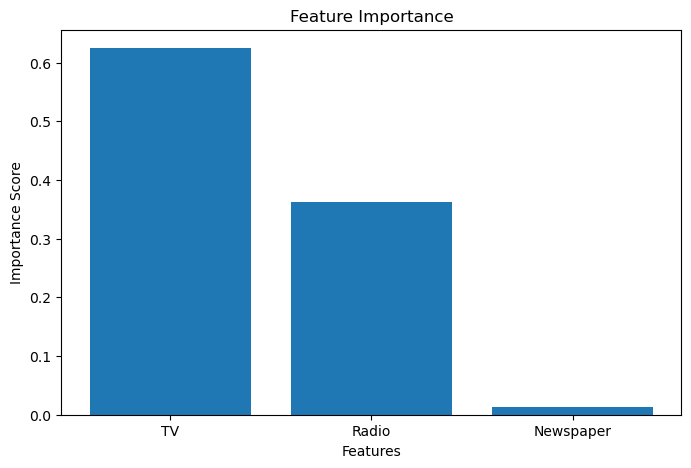

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.show()

Insights: TV advertising is the most influential factor affecting sales, which contributes approximately 65% of the model's decision-making.

In [29]:
import pickle

with open("sales_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [30]:
importance_df.to_csv("feature_importance.csv", index=False)